## Data-Driven Market Entry Analysis Predicting Vehicle Purchase Propensity for ABG Motors in India

In [98]:

# ABG Motors – Market Entry Analysis for India

# --------------------------------------------------------------
# 0. IMPORTS & SETUP
# --------------------------------------------------------------
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, classification_report,
                             roc_curve, precision_recall_curve)

from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Jupyter display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (11, 6)
plt.rcParams['font.size'] = 11

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [99]:
# --------------------------------------------------------------
# 1. LOAD DATA
# --------------------------------------------------------------
jpn = pd.read_excel("JPN Data.xlsx")   # Japanese market
ind = pd.read_excel("IN_Data.xlsx")    # Indian market

print("Japanese dataset shape:", jpn.shape)
print("Indian dataset shape  :", ind.shape)
print("\nJapanese columns:", jpn.columns.tolist())
print("Indian columns  :", ind.columns.tolist())

Japanese dataset shape: (40000, 6)
Indian dataset shape  : (70000, 5)

Japanese columns: ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']
Indian columns  : ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'DT_MAINT']


In [100]:
jpn.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,445344.0000,439,0
1,00003I71CQ,35,M,107634.0000,283,0
2,00003N47FS,59,F,502786.6667,390,1
3,00005H41DE,43,M,585664.0000,475,0
4,00007E17UM,39,F,705722.6667,497,1


In [101]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,1425390,2018-04-20
1,89602T51HX,47,M,1678954,2018-06-08
2,70190Z52IP,60,M,931624,2017-07-31
3,25623V15MU,55,F,1106320,2017-07-31
4,36230I68CE,32,F,748465,2019-01-27


In [102]:
# =============================================================================
# 2. FEATURE ENGINEERING (exact bins required by the company brief)
# =============================================================================
def bin_age_car(days):
    """Create the 4 segments mandated by ABG Motors."""
    if days < 200:
        return 1
    elif 200 <= days <= 360:
        return 2
    elif 360 < days <= 500:
        return 3
    else:
        return 4

jpn['AGE_SEG'] = jpn['AGE_CAR'].apply(bin_age_car)
jpn['GENDER_ENC'] = (jpn['GENDER'] == 'M').astype(int)

# Indian analysis date fixed at 1 July 2019 (per assumptions)
ind['AGE_CAR'] = (pd.Timestamp('2019-07-01') - ind['DT_MAINT']).dt.days
ind['AGE_SEG'] = ind['AGE_CAR'].apply(bin_age_car)
ind['GENDER_ENC'] = (ind['GENDER'] == 'M').astype(int)

print('\nFeature engineering completed (AGE_SEG bins + Gender encoding).')


Feature engineering completed (AGE_SEG bins + Gender encoding).


In [103]:
jpn.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE,AGE_SEG,GENDER_ENC
0,00001Q15YJ,50,M,445344.0000,439,0,3,1
1,00003I71CQ,35,M,107634.0000,283,0,2,1
2,00003N47FS,59,F,502786.6667,390,1,3,0
3,00005H41DE,43,M,585664.0000,475,0,3,1
4,00007E17UM,39,F,705722.6667,497,1,3,0


In [104]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR,AGE_SEG,GENDER_ENC
0,20710B05XL,54,M,1425390,2018-04-20,437,3,1
1,89602T51HX,47,M,1678954,2018-06-08,388,3,1
2,70190Z52IP,60,M,931624,2017-07-31,700,4,1
3,25623V15MU,55,F,1106320,2017-07-31,700,4,0
4,36230I68CE,32,F,748465,2019-01-27,155,1,0


In [105]:
# --------------------------------------------------------------
# 3. DATA QUALITY &  EXPLORATION
# --------------------------------------------------------------
print("\n===== DATA QUALITY CHECK =====")
print("Japan missing values:\n", jpn.isnull().sum())
print("\nIndia missing values:\n", ind.isnull().sum())

print("\n===== SQL-STYLE AGGREGATIONS (Japan) =====")
# Equivalent to: SELECT GENDER, COUNT(*), AVG(PURCHASE) FROM jpn GROUP BY GENDER
print(jpn.groupby('GENDER').agg(
    customers=('ID', 'count'),
    purchase_rate=('PURCHASE', 'mean'),
    avg_income=('ANN_INCOME', 'mean'),
    avg_age=('CURR_AGE', 'mean')
).round(3))

print("\n===== BASIC STATISTICS =====")
print(jpn[['CURR_AGE', 'ANN_INCOME', 'AGE_CAR', 'PURCHASE']].describe().round(2))

# --------------------------------------------------------------
# 3. FEATURE ENGINEERING (Exact rules from Capstone brief)
# --------------------------------------------------------------
def bin_age_car(days):
    """Exact segments required by ABG Motors"""
    if days < 200:
        return 1
    elif 200 <= days <= 360:
        return 2
    elif 360 < days <= 500:
        return 3
    else:
        return 4

# Japan
jpn['AGE_SEG'] = jpn['AGE_CAR'].apply(bin_age_car)
jpn['GENDER_ENC'] = (jpn['GENDER'] == 'M').astype(int)

# India – fixed analysis date = 1 July 2019 (as per brief)
ind['AGE_CAR'] = (pd.Timestamp('2019-07-01') - ind['DT_MAINT']).dt.days
ind['AGE_SEG'] = ind['AGE_CAR'].apply(bin_age_car)
ind['GENDER_ENC'] = (ind['GENDER'] == 'M').astype(int)

print("\n===== AGE_SEG DISTRIBUTION & PURCHASE RATE (Japan) =====")
seg_summary = jpn.groupby('AGE_SEG').agg(
    customers=('ID', 'count'),
    purchase_rate=('PURCHASE', 'mean')
).round(3)
print(seg_summary)


===== DATA QUALITY CHECK =====
Japan missing values:
 ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
AGE_SEG       0
GENDER_ENC    0
dtype: int64

India missing values:
 ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
DT_MAINT      0
AGE_CAR       0
AGE_SEG       0
GENDER_ENC    0
dtype: int64

===== SQL-STYLE AGGREGATIONS (Japan) =====
        customers  purchase_rate  avg_income  avg_age
GENDER                                               
F           17715         0.5550 364629.3610  45.2080
M           22285         0.5920 355241.0140  44.8300

===== BASIC STATISTICS =====
        CURR_AGE  ANN_INCOME    AGE_CAR   PURCHASE
count 40000.0000  40000.0000 40000.0000 40000.0000
mean     45.0000 359398.8800   359.0800     0.5800
std      11.8200 175109.2600   203.0600     0.4900
min      25.0000  70089.0000     1.0000     0.0000
25%      35.0000 219766.0000   235.0000     0.0000
50%      45.0000 337656.8300   331.0000    

In [106]:
jpn.head(3)

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE,AGE_SEG,GENDER_ENC
0,00001Q15YJ,50,M,445344.0000,439,0,3,1
1,00003I71CQ,35,M,107634.0000,283,0,2,1
2,00003N47FS,59,F,502786.6667,390,1,3,0


In [107]:
ind.head(3)

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT,AGE_CAR,AGE_SEG,GENDER_ENC
0,20710B05XL,54,M,1425390,2018-04-20,437,3,1
1,89602T51HX,47,M,1678954,2018-06-08,388,3,1
2,70190Z52IP,60,M,931624,2017-07-31,700,4,1


In [108]:
# --------------------------------------------------------------
# 4. visualization
# --------------------------------------------------------------
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio

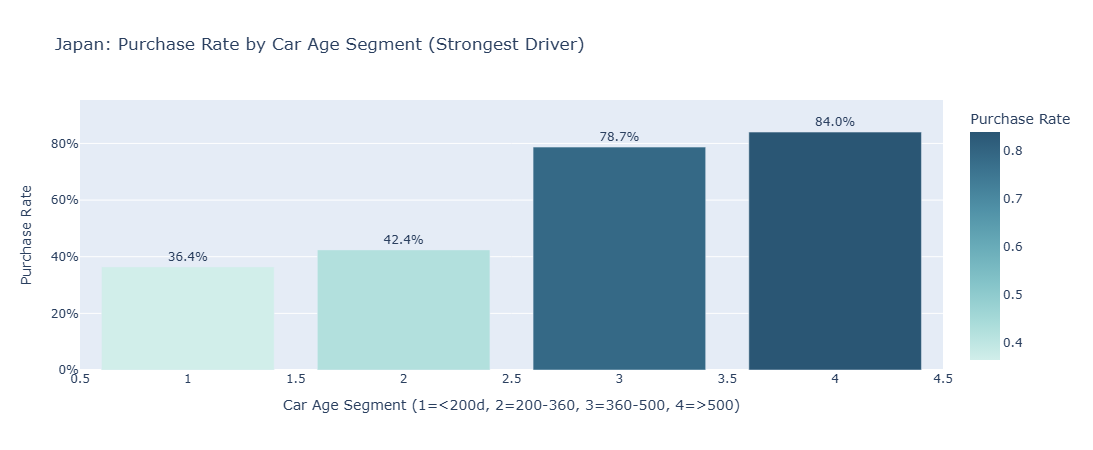

In [109]:
# 4.1 Purchase rate by AGE_SEG (Japan)
fig1 = px.bar(
    seg_summary.reset_index(),
    x='AGE_SEG', y='purchase_rate',
    text=seg_summary['purchase_rate'].apply(lambda x: f"{x:.1%}"),
    title="Japan: Purchase Rate by Car Age Segment (Strongest Driver)",
    labels={'AGE_SEG': 'Car Age Segment (1=<200d, 2=200-360, 3=360-500, 4=>500)',
            'purchase_rate': 'Purchase Rate'},
    color='purchase_rate', color_continuous_scale='Teal'
)
fig1.update_traces(textposition='outside')
fig1.update_layout(yaxis_tickformat='.0%', height=450)
fig1.show()

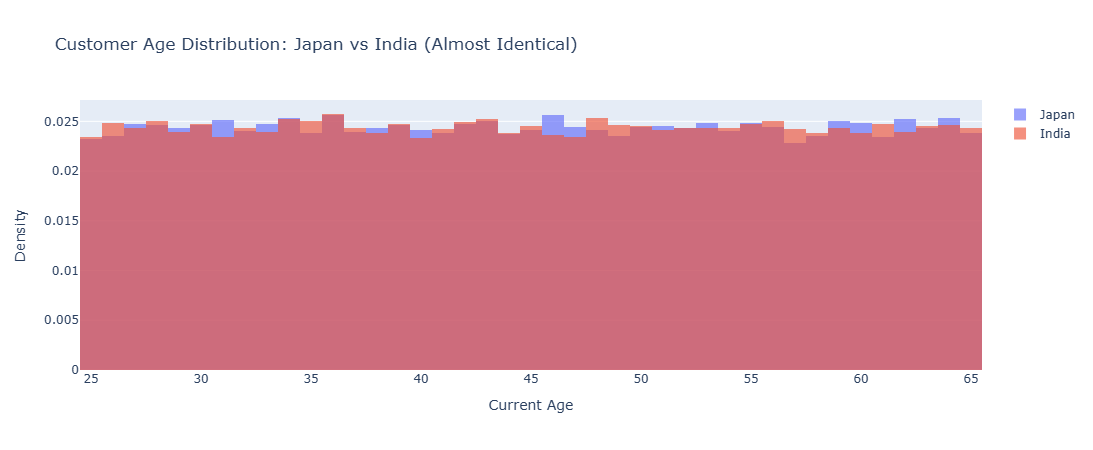

In [110]:
# 4.2 Age distribution comparison (Japan vs India)
fig2 = go.Figure()
fig2.add_trace(go.Histogram(x=jpn['CURR_AGE'], name='Japan', opacity=0.65, histnorm='probability density'))
fig2.add_trace(go.Histogram(x=ind['CURR_AGE'], name='India', opacity=0.65, histnorm='probability density'))
fig2.update_layout(
    title="Customer Age Distribution: Japan vs India (Almost Identical)",
    barmode='overlay', xaxis_title="Current Age", yaxis_title="Density", height=450
)
fig2.show()

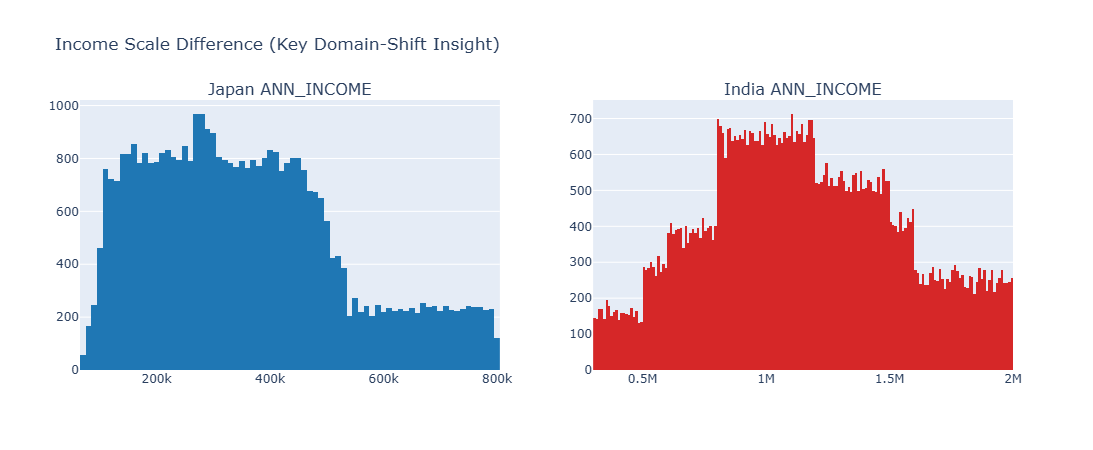


===== DOMAIN SHIFT CHECK: INCOME SCALE =====
Japan ANN_INCOME mean: 359399
India ANN_INCOME mean: 1148679
India mean is about 3.2 times Japan mean
Do not treat raw India income as the same unit as Japan income.


In [111]:
# 4.3 Income distribution comparison (critical insight)
fig3 = make_subplots(rows=1, cols=2, subplot_titles=("Japan ANN_INCOME", "India ANN_INCOME"))
fig3.add_trace(go.Histogram(x=jpn['ANN_INCOME'], name='Japan', marker_color='#1f77b4'), row=1, col=1)
fig3.add_trace(go.Histogram(x=ind['ANN_INCOME'], name='India', marker_color='#d62728'), row=1, col=2)
fig3.update_layout(title_text="Income Scale Difference (Key Domain-Shift Insight)", height=450, showlegend=False)
fig3.show()
print("\n===== DOMAIN SHIFT CHECK: INCOME SCALE =====")
print("Japan ANN_INCOME mean:", round(jpn['ANN_INCOME'].mean()))
print("India ANN_INCOME mean:", round(ind['ANN_INCOME'].mean()))
print("India mean is about", round(ind['ANN_INCOME'].mean() / jpn['ANN_INCOME'].mean(), 1), "times Japan mean")
print("Do not treat raw India income as the same unit as Japan income.")

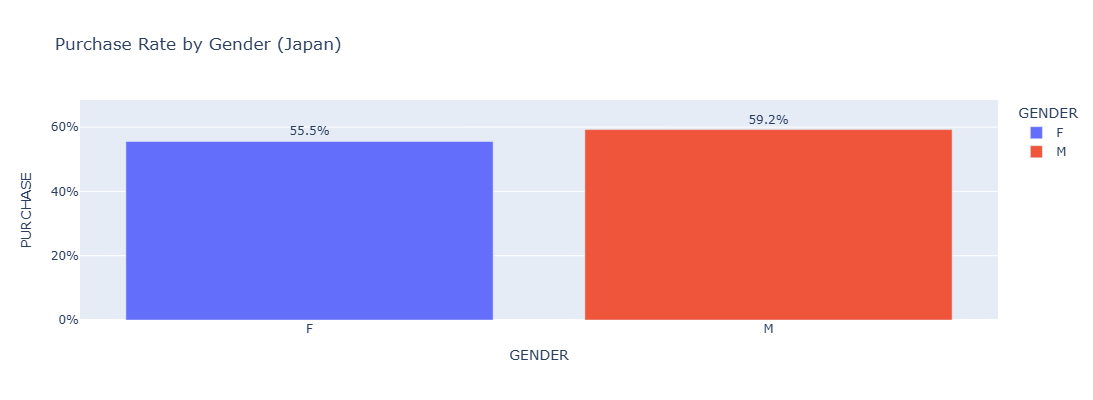

In [112]:
# 4.4 Purchase rate by Gender
gender_rate = jpn.groupby('GENDER')['PURCHASE'].mean().reset_index()
fig4 = px.bar(gender_rate, x='GENDER', y='PURCHASE', text='PURCHASE',
              title="Purchase Rate by Gender (Japan)", color='GENDER')
fig4.update_traces(texttemplate='%{text:.1%}', textposition='outside')
fig4.update_layout(yaxis_tickformat='.0%', height=400)
fig4.show()

In [113]:
# --------------------------------------------------------------
# 5. PREPARE MODELING MATRIX
# --------------------------------------------------------------
features = ['CURR_AGE', 'GENDER_ENC', 'ANN_INCOME', 'AGE_SEG']

X = pd.get_dummies(jpn[features], columns=['AGE_SEG'], prefix='AGE_SEG', drop_first=True)
y = jpn['PURCHASE']

# Standardize numerical features (important for Logistic Regression stability)
scaler = StandardScaler()
num_cols = ['CURR_AGE', 'ANN_INCOME']
X[num_cols] = scaler.fit_transform(X[num_cols])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print("Training set:", X_train.shape, " | Test set:", X_test.shape)

Training set: (30000, 6)  | Test set: (10000, 6)


In [114]:
# --------------------------------------------------------------
# 6. MODEL TRAINING
# --------------------------------------------------------------
# Primary model – Logistic Regression (interpretable)
log_reg = LogisticRegression(max_iter=2000, random_state=42, C=1.0)
log_reg.fit(X_train, y_train)

# Comparison model – XGBoost (modern performance)
xgb = XGBClassifier(
    n_estimators=200, max_depth=5, learning_rate=0.06,
    subsample=0.85, colsample_bytree=0.8, min_child_weight=5,
    random_state=42, eval_metric='logloss', n_jobs=-1, verbosity=0
)
xgb.fit(X_train, y_train)

print("Both models trained successfully.")

Both models trained successfully.


In [115]:
# --------------------------------------------------------------
# 7. MODEL EVALUATION & COMPARISON
# --------------------------------------------------------------
def evaluate_model(model, X_test, y_test, name):
    proba = model.predict_proba(X_test)[:, 1]
    pred  = model.predict(X_test)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'ROC-AUC': roc_auc_score(y_test, proba)
    }

results = [
    evaluate_model(log_reg, X_test, y_test, "Logistic Regression (Primary)"),
    evaluate_model(xgb, X_test, y_test, "XGBoost (Comparison)")
]
results_df = pd.DataFrame(results).round(4)
print("\n===== MODEL PERFORMANCE COMPARISON (Hold-out Test) =====")
print(results_df.to_string(index=False))


===== MODEL PERFORMANCE COMPARISON (Hold-out Test) =====
                        Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
Logistic Regression (Primary)    0.6864     0.7442  0.6938    0.7181   0.7600
         XGBoost (Comparison)    0.6979     0.7478  0.7173    0.7322   0.7812


In [116]:
# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("\n===== 5-FOLD CROSS-VALIDATION ROC-AUC =====")
for name, model in [("Logistic Regression", log_reg), ("XGBoost", xgb)]:
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"{name:25s}: {scores.mean():.4f} ± {scores.std()*2:.4f}")


===== 5-FOLD CROSS-VALIDATION ROC-AUC =====
Logistic Regression      : 0.7537 ± 0.0079
XGBoost                  : 0.7773 ± 0.0111


In [117]:
# --------------------------------------------------------------
# 8. COEFFICIENT INTERPRETATION 
# --------------------------------------------------------------
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient (log-odds)': log_reg.coef_[0],
    'Odds Ratio': np.exp(log_reg.coef_[0])
}).sort_values('Odds Ratio', ascending=False)

print("\n===== LOGISTIC REGRESSION COEFFICIENTS & BUSINESS INTERPRETATION =====")
print(coef_df.round(4).to_string(index=False))
print(f"\nIntercept (log-odds): {log_reg.intercept_[0]:.4f}")
print("""
BUSINESS INTERPRETATION:
• AGE_SEG_4 (>500 days since maintenance): Odds Ratio ≈ 10×  
  → Customers whose car is more than 500 days old are roughly 10 times more likely 
    to purchase a new vehicle than the reference group (<200 days), holding other factors constant.
• AGE_SEG_3 (360–500 days): Odds Ratio ≈ 6.7×  
  → Still a very strong positive driver of purchase likelihood.
• ANN_INCOME: Higher income increases purchase probability (as expected).
• GENDER (Male): Modest positive effect (~1.2× odds).
• CURR_AGE: Slightly negative effect after controlling for car age.
""")


===== LOGISTIC REGRESSION COEFFICIENTS & BUSINESS INTERPRETATION =====
   Feature  Coefficient (log-odds)  Odds Ratio
 AGE_SEG_4                  2.3124     10.0990
 AGE_SEG_3                  1.9035      6.7093
ANN_INCOME                  0.4404      1.5533
 AGE_SEG_2                  0.2806      1.3240
GENDER_ENC                  0.2057      1.2284
  CURR_AGE                 -0.1363      0.8726

Intercept (log-odds): -0.6906

BUSINESS INTERPRETATION:
• AGE_SEG_4 (>500 days since maintenance): Odds Ratio ≈ 10×  
  → Customers whose car is more than 500 days old are roughly 10 times more likely 
    to purchase a new vehicle than the reference group (<200 days), holding other factors constant.
• AGE_SEG_3 (360–500 days): Odds Ratio ≈ 6.7×  
  → Still a very strong positive driver of purchase likelihood.
• ANN_INCOME: Higher income increases purchase probability (as expected).
• GENDER (Male): Modest positive effect (~1.2× odds).
• CURR_AGE: Slightly negative effect after controlling f


===== XGBOOST FEATURE IMPORTANCE =====
AGE_SEG_3    0.4451
AGE_SEG_4    0.3831
AGE_SEG_2    0.0953
ANN_INCOME   0.0421
GENDER_ENC   0.0194
CURR_AGE     0.0150


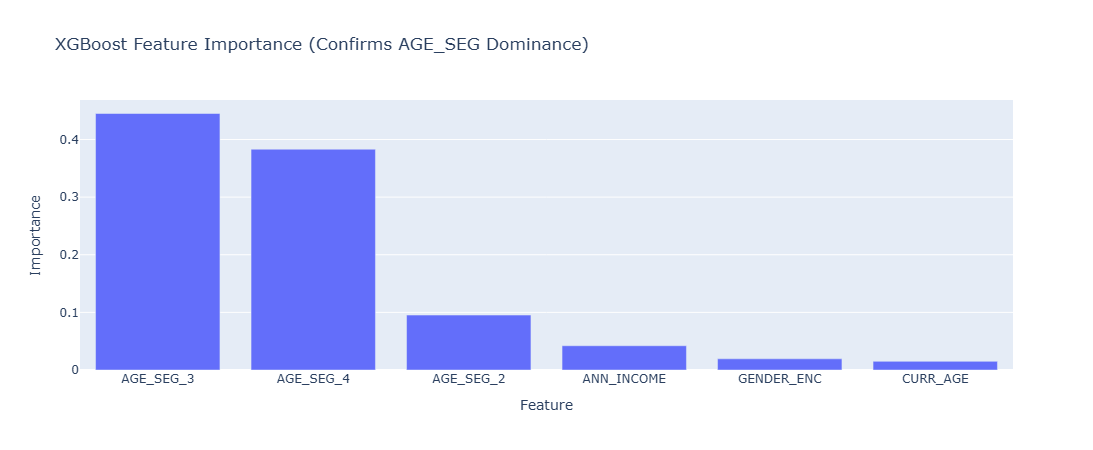

In [118]:
# --------------------------------------------------------------
# 9. XGBOOST FEATURE IMPORTANCE
# --------------------------------------------------------------
imp = pd.Series(xgb.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\n===== XGBOOST FEATURE IMPORTANCE =====")
print(imp.round(4).to_string())

fig_imp = px.bar(
    imp.reset_index(), x='index', y=0,
    title="XGBoost Feature Importance (Confirms AGE_SEG Dominance)",
    labels={'index': 'Feature', '0': 'Importance'}
)
fig_imp.update_layout(height=450)
fig_imp.show()

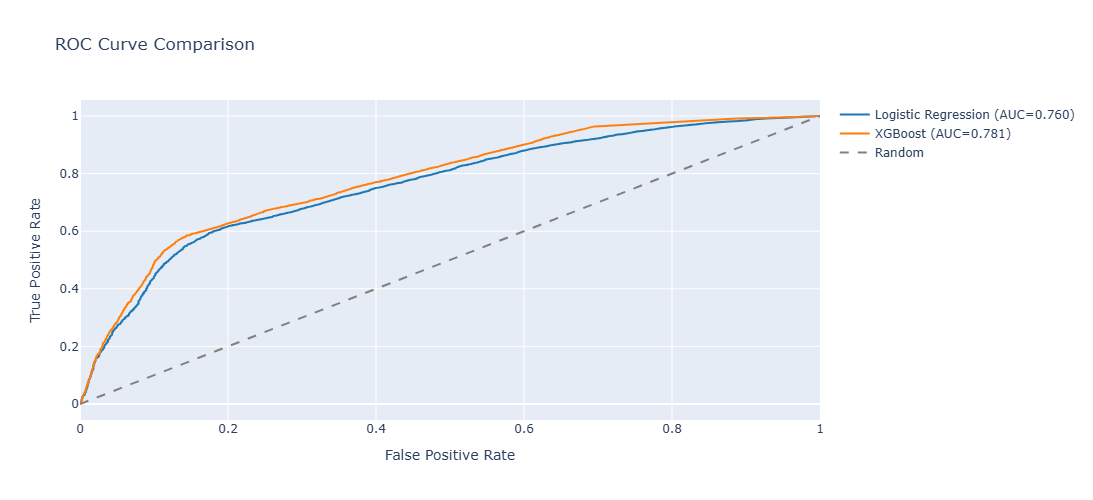

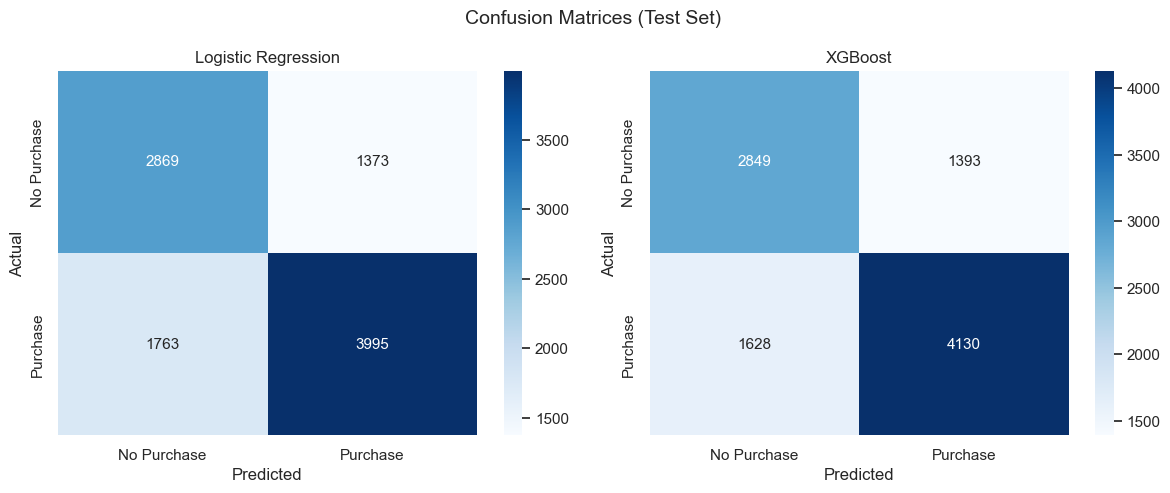

In [119]:
# --------------------------------------------------------------
# 10. ROC CURVES & CONFUSION MATRICES (Interactive + Static)
# --------------------------------------------------------------
# ROC comparison
fig_roc = go.Figure()
for model, name, color in [(log_reg, "Logistic Regression", "#1f77b4"),
                           (xgb, "XGBoost", "#ff7f0e")]:
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc_val = roc_auc_score(y_test, proba)
    fig_roc.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f"{name} (AUC={auc_val:.3f})",
                                 line=dict(color=color, width=2)))
fig_roc.add_trace(go.Scatter(x=[0,1], y=[0,1], mode='lines', name='Random',
                             line=dict(dash='dash', color='gray')))
fig_roc.update_layout(title="ROC Curve Comparison", xaxis_title="False Positive Rate",
                      yaxis_title="True Positive Rate", height=500)
fig_roc.show()

# Confusion matrices
fig_cm, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, model, title in zip(axes, [log_reg, xgb], ["Logistic Regression", "XGBoost"]):
    cm = confusion_matrix(y_test, model.predict(X_test))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Purchase', 'Purchase'],
                yticklabels=['No Purchase', 'Purchase'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')
plt.suptitle("Confusion Matrices (Test Set)", fontsize=14)
plt.tight_layout()
plt.show()

In [120]:
# --------------------------------------------------------------
# 11. SCORE INDIAN MARKET
# --------------------------------------------------------------
X_ind = pd.get_dummies(ind[features], columns=['AGE_SEG'], prefix='AGE_SEG', drop_first=True)

# Align columns
for col in X.columns:
    if col not in X_ind.columns:
        X_ind[col] = 0
X_ind = X_ind[X.columns]
X_ind[num_cols] = scaler.transform(X_ind[num_cols])   # Use Japan scaler

# Predictions
ind['proba_logreg'] = log_reg.predict_proba(X_ind)[:, 1]
ind['pred_logreg']  = (ind['proba_logreg'] >= 0.5).astype(int)

ind['proba_xgb'] = xgb.predict_proba(X_ind)[:, 1]
ind['pred_xgb']  = (ind['proba_xgb'] >= 0.5).astype(int)

print("\n===== INDIAN MARKET FORECAST =====")
print(f"Sample size                              : {len(ind):,}")
print(f"\n--- Logistic Regression (Primary) ---")
print(f"Predicted buyers (p ≥ 0.5)               : {ind['pred_logreg'].sum():,}")
print(f"Expected sales (sum of probabilities)    : {ind['proba_logreg'].sum():,.0f}")
print(f"Mean purchase probability                : {ind['proba_logreg'].mean():.1%}")

print(f"\n--- XGBoost (Comparison) ---")
print(f"Predicted buyers (p ≥ 0.5)               : {ind['pred_xgb'].sum():,}")
print(f"Expected sales (sum of probabilities)    : {ind['proba_xgb'].sum():,.0f}")
print(f"Mean purchase probability                : {ind['proba_xgb'].mean():.1%}")

# Threshold sensitivity
print("\n===== THRESHOLD SENSITIVITY (Logistic) =====")
for thresh in [0.5, 0.6, 0.7, 0.8]:
    buyers = (ind['proba_logreg'] >= thresh).sum()
    print(f"p ≥ {thresh:.1f}: {buyers:,} potential buyers")


===== INDIAN MARKET FORECAST =====
Sample size                              : 70,000

--- Logistic Regression (Primary) ---
Predicted buyers (p ≥ 0.5)               : 67,362
Expected sales (sum of probabilities)    : 60,318
Mean purchase probability                : 86.2%

--- XGBoost (Comparison) ---
Predicted buyers (p ≥ 0.5)               : 50,325
Expected sales (sum of probabilities)    : 46,835
Mean purchase probability                : 66.9%

===== THRESHOLD SENSITIVITY (Logistic) =====
p ≥ 0.5: 67,362 potential buyers
p ≥ 0.6: 64,988 potential buyers
p ≥ 0.7: 60,399 potential buyers
p ≥ 0.8: 52,265 potential buyers


In [125]:
# --------------------------------------------------------------
# 11b. DOMAIN-SHIFT SENSITIVITY (income-aligned India score)
# --------------------------------------------------------------
# Map each Indian income to the Japan income at the same percentile,
# then reuse the same Japan model + Japan scaler.

ind_pct = ind['ANN_INCOME'].rank(pct=True, method='average')
ind_income_aligned = np.quantile(jpn['ANN_INCOME'], ind_pct)

X_ind_aligned = X_ind.copy()
aligned_num = pd.DataFrame({
    'CURR_AGE': ind['CURR_AGE'].values,
    'ANN_INCOME': ind_income_aligned
})[num_cols]
X_ind_aligned[num_cols] = scaler.transform(aligned_num)


ind['proba_logreg_aligned'] = log_reg.predict_proba(X_ind_aligned)[:, 1]
ind['pred_logreg_aligned'] = (ind['proba_logreg_aligned'] >= 0.5).astype(int)

ind['proba_xgb_aligned'] = xgb.predict_proba(X_ind_aligned)[:, 1]
ind['pred_xgb_aligned'] = (ind['proba_xgb_aligned'] >= 0.5).astype(int)

print("\n===== DOMAIN-SHIFT SENSITIVITY =====")
print("Logistic Regression unadjusted")
print("  Expected sales :", round(ind['proba_logreg'].sum()))
print("  Mean probability:", f"{ind['proba_logreg'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_logreg'].sum()))

print("Logistic Regression income-aligned")
print("  Expected sales :", round(ind['proba_logreg_aligned'].sum()))
print("  Mean probability:", f"{ind['proba_logreg_aligned'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_logreg_aligned'].sum()))

print("XGBoost unadjusted")
print("  Expected sales :", round(ind['proba_xgb'].sum()))
print("  Mean probability:", f"{ind['proba_xgb'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_xgb'].sum()))

print("XGBoost income-aligned")
print("  Expected sales :", round(ind['proba_xgb_aligned'].sum()))
print("  Mean probability:", f"{ind['proba_xgb_aligned'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_xgb_aligned'].sum()))

print("Primary decision model: Logistic Regression")
print("Use the Logistic income-aligned to unadjusted range vs 12,000.")


===== DOMAIN-SHIFT SENSITIVITY =====
Logistic Regression unadjusted
  Expected sales : 60318
  Mean probability: 86.2%
  Buyers p>=0.5   : 67362
Logistic Regression income-aligned
  Expected sales : 40987
  Mean probability: 58.6%
  Buyers p>=0.5   : 39306
XGBoost unadjusted
  Expected sales : 46835
  Mean probability: 66.9%
  Buyers p>=0.5   : 50325
XGBoost income-aligned
  Expected sales : 40529
  Mean probability: 57.9%
  Buyers p>=0.5   : 39064
Primary decision model: Logistic Regression
Use the Logistic income-aligned to unadjusted range vs 12,000.


In [126]:
# --------------------------------------------------------------
# 11b. DOMAIN-SHIFT SENSITIVITY (income-aligned India score)
# --------------------------------------------------------------
# Keep unadjusted scores. Add a fairer score:
# map each Indian income to the Japan income at the same percentile,
# then reuse the same Japan model + Japan scaler.

ind_pct = ind['ANN_INCOME'].rank(pct=True, method='average')
ind_income_aligned = np.quantile(jpn['ANN_INCOME'], ind_pct)

# Scaler was fit on ['CURR_AGE', 'ANN_INCOME'], so transform both columns
X_ind_aligned = X_ind.copy()
aligned_num = pd.DataFrame({
    'CURR_AGE': ind['CURR_AGE'].values,
    'ANN_INCOME': ind_income_aligned
})[num_cols]
X_ind_aligned[num_cols] = scaler.transform(aligned_num)

ind['proba_xgb_aligned'] = xgb.predict_proba(X_ind_aligned)[:, 1]
ind['pred_xgb_aligned'] = (ind['proba_xgb_aligned'] >= 0.5).astype(int)

print("\n===== DOMAIN-SHIFT SENSITIVITY =====")
print("Logistic Regression unadjusted")
print("  Expected sales :", round(ind['proba_logreg'].sum()))
print("  Mean probability:", f"{ind['proba_logreg'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_logreg'].sum()))

print("Logistic Regression income-aligned")
print("  Expected sales :", round(ind['proba_logreg_aligned'].sum()))
print("  Mean probability:", f"{ind['proba_logreg_aligned'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_logreg_aligned'].sum()))

print("XGBoost unadjusted")
print("  Expected sales :", round(ind['proba_xgb'].sum()))
print("  Mean probability:", f"{ind['proba_xgb'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_xgb'].sum()))

print("XGBoost income-aligned")
print("  Expected sales :", round(ind['proba_xgb_aligned'].sum()))
print("  Mean probability:", f"{ind['proba_xgb_aligned'].mean():.1%}")
print("  Buyers p>=0.5   :", int(ind['pred_xgb_aligned'].sum()))

print("Primary decision model: Logistic Regression")
print("Use the Logistic income-aligned to unadjusted range vs 12,000.")


===== DOMAIN-SHIFT SENSITIVITY =====
Logistic Regression unadjusted
  Expected sales : 60318
  Mean probability: 86.2%
  Buyers p>=0.5   : 67362
Logistic Regression income-aligned
  Expected sales : 40987
  Mean probability: 58.6%
  Buyers p>=0.5   : 39306
XGBoost unadjusted
  Expected sales : 46835
  Mean probability: 66.9%
  Buyers p>=0.5   : 50325
XGBoost income-aligned
  Expected sales : 40529
  Mean probability: 57.9%
  Buyers p>=0.5   : 39064
Primary decision model: Logistic Regression
Use the Logistic income-aligned to unadjusted range vs 12,000.


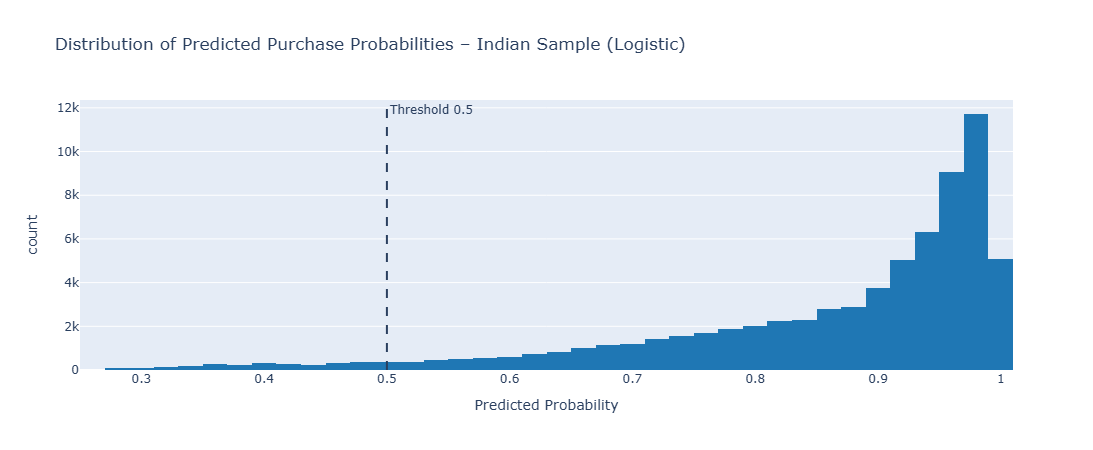

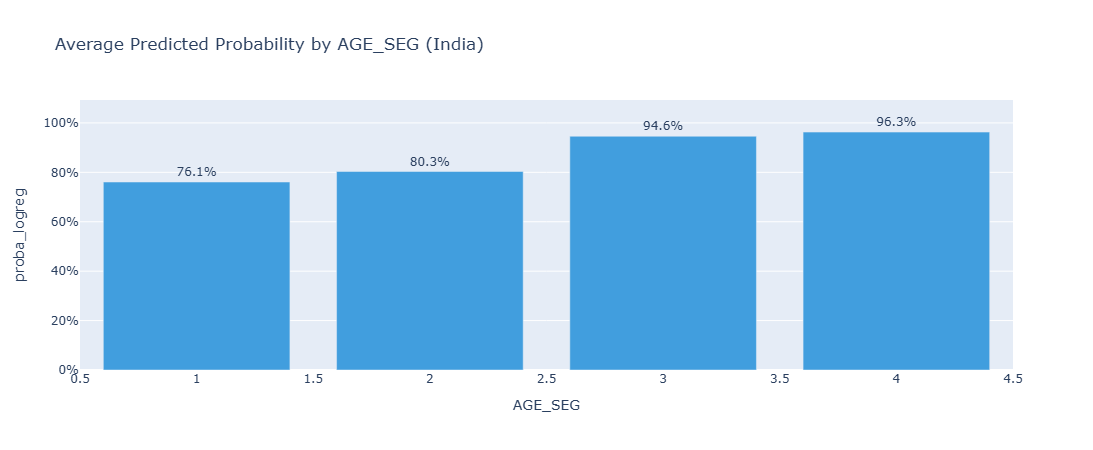

In [127]:
# --------------------------------------------------------------
# 12. INDIAN PREDICTION VISUALIZATIONS
# --------------------------------------------------------------
fig_proba = px.histogram(
    ind, x='proba_logreg', nbins=50,
    title="Distribution of Predicted Purchase Probabilities – Indian Sample (Logistic)",
    labels={'proba_logreg': 'Predicted Probability'}
)
fig_proba.add_vline(x=0.5, line_dash="dash", annotation_text="Threshold 0.5")
fig_proba.update_traces(marker_color='#1f77b4')
fig_proba.update_layout(height=450)
fig_proba.show()

# AGE_SEG effect on Indian predictions
seg_pred = ind.groupby('AGE_SEG')['proba_logreg'].mean().reset_index()
fig_seg = px.bar(seg_pred, x='AGE_SEG', y='proba_logreg',
                 title="Average Predicted Probability by AGE_SEG (India)",
                 text=seg_pred['proba_logreg'].apply(lambda x: f"{x:.1%}"))
fig_seg.update_traces(textposition='outside',marker_color='#419ede')
fig_seg.update_layout(yaxis_tickformat='.0%', height=450)
fig_seg.show()

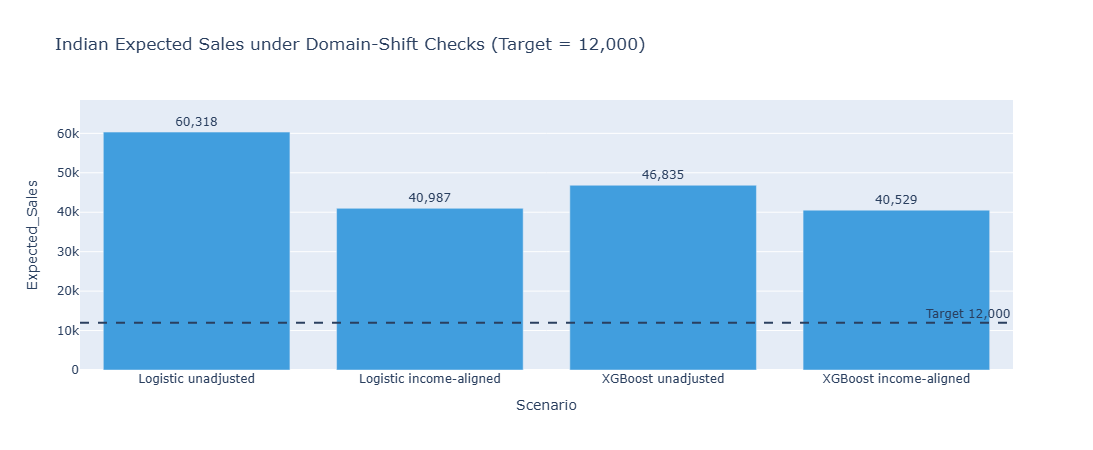

In [128]:
# Domain-shift comparison
cmp = pd.DataFrame({
    'Scenario': [
        'Logistic unadjusted',
        'Logistic income-aligned',
        'XGBoost unadjusted',
        'XGBoost income-aligned'
    ],
    'Expected_Sales': [
        ind['proba_logreg'].sum(),
        ind['proba_logreg_aligned'].sum(),
        ind['proba_xgb'].sum(),
        ind['proba_xgb_aligned'].sum()
    ]
})
fig_shift = px.bar(
    cmp, x='Scenario', y='Expected_Sales', text='Expected_Sales',
    title='Indian Expected Sales under Domain-Shift Checks (Target = 12,000)'
)
fig_shift.update_traces(texttemplate='%{text:,.0f}', textposition='outside',marker_color='#419ede')
fig_shift.add_hline(y=12000, line_dash='dash', annotation_text='Target 12,000')
fig_shift.update_layout(height=450)
fig_shift.show()

In [129]:
# --------------------------------------------------------------
# 13. SAVE OUTPUTS
# --------------------------------------------------------------
output_cols = ['ID', 'CURR_AGE', 'GENDER', 'ANN_INCOME', 'AGE_CAR', 'AGE_SEG',
               'proba_logreg', 'pred_logreg',
               'proba_logreg_aligned', 'pred_logreg_aligned',
               'proba_xgb', 'pred_xgb',
               'proba_xgb_aligned', 'pred_xgb_aligned']
ind[output_cols].to_csv("Indian_Scored_Customers.csv", index=False)
print("\nScored Indian customer file saved → Indian_Scored_Customers.csv")

results_df.to_csv("Model_Performance_Comparison.csv", index=False)
coef_df.to_csv("Logistic_Coefficients.csv", index=False)
print("Model performance & coefficients also saved.")


Scored Indian customer file saved → Indian_Scored_Customers.csv
Model performance & coefficients also saved.
